# VAR, IRF và FEVD cho phân tích cú sốc chính sách

Notebook này mở rộng phần VAR hiện có bằng các đầu ra mà báo cáo kinh tế lượng thường cần:

- **IRF**: GDP growth phản ứng thế nào trước shock lạm phát / lãi suất.
- **FEVD**: biến động GDP growth được giải thích bao nhiêu bởi shock của từng biến.
- **Granger causality** và **diagnostics** ở cùng một chỗ.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from IPython.display import display, Markdown

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("secondary_data_annual.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Không tìm thấy secondary_data_annual.csv")

df = pd.read_csv(DATA_PATH)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df = df.sort_values("Year").reset_index(drop=True)

# Thứ tự biến phản ánh một ordering chính sách đơn giản:
VAR_VARS = ["Interest_Rate", "Inflation", "GDP_Growth"]

var_df = df[["Year"] + VAR_VARS].dropna().copy()
display(var_df.head())


,Year,Interest_Rate,Inflation,GDP_Growth
1,1996,20.100,5.675,9.340
2,1997,14.417,3.210,8.152
3,1998,14.400,7.266,5.764
4,1999,12.700,4.117,4.774
5,2000,10.550,-1.710,6.787


## 1. Kiểm tra stationarity và tự động differencing nếu cần


In [2]:

def adf_p(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 10:
        return np.nan
    return adfuller(s, autolag="AIC")[1]

stationarity_rows = []
var_work = var_df.copy()

for col in VAR_VARS:
    p_level = adf_p(var_work[col])
    transform = "level"
    if pd.notna(p_level) and p_level > 0.10:
        var_work[col] = var_work[col].diff()
        transform = "diff1"
    stationarity_rows.append({
        "series": col,
        "adf_p_level": p_level,
        "transform_used": transform,
        "adf_p_after_transform": adf_p(var_work[col]),
    })

stationarity_table = pd.DataFrame(stationarity_rows)
stationarity_table.to_csv(OUTPUT_DIR / "03_stationarity_for_var.csv", index=False)
display(stationarity_table)

var_work = var_work.dropna().reset_index(drop=True)
display(var_work.head())


,series,adf_p_level,transform_used,adf_p_after_transform
0,Interest_Rate,0.010051,level,1.005146e-02
1,Inflation,0.024278,level,2.427780e-02
2,GDP_Growth,0.340425,diff1,9.218422e-12


,Year,Interest_Rate,Inflation,GDP_Growth
0,1997,14.417,3.210,-1.188
1,1998,14.400,7.266,-2.388
2,1999,12.700,4.117,-0.990
3,2000,10.550,-1.710,2.013
4,2001,9.420,-0.432,-0.594


## 2. Chọn độ trễ và ước lượng VAR


In [3]:

maxlags = min(4, max(1, len(var_work) // 4))
selector = VAR(var_work[VAR_VARS]).select_order(maxlags=maxlags)

selected_lag = selector.aic
if selected_lag is None or np.isnan(selected_lag):
    selected_lag = 1
selected_lag = int(selected_lag) if int(selected_lag) >= 1 else 1

var_res = VAR(var_work[VAR_VARS]).fit(selected_lag)

display(Markdown(f"**Độ trễ được chọn theo AIC:** {selected_lag}"))
display(var_res.summary())


**Độ trễ được chọn theo AIC:** 2

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     08:22:27
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    5.65341
Nobs:                     25.0000    HQIC:                   4.91352
Log likelihood:          -143.290    FPE:                    107.301
AIC:                      4.62955    Det(Omega_mle):         51.1653
--------------------------------------------------------------------
Results for equation Interest_Rate
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    2.977526         2.054569            1.449           0.147
L1.Interest_Rate         1.365142         0.518386            2.633           0.008
L1.Inflation            -0.299219       

## 3. Diagnostics


In [4]:

diag_rows = [
    {"metric": "is_stable", "value": bool(var_res.is_stable())},
]

try:
    whiteness = var_res.test_whiteness(nlags=max(selected_lag + 2, 4))
    diag_rows.append({"metric": "whiteness_pvalue", "value": float(whiteness.pvalue)})
except Exception:
    pass

try:
    normality = var_res.test_normality()
    diag_rows.append({"metric": "normality_pvalue", "value": float(normality.pvalue)})
except Exception:
    pass

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUTPUT_DIR / "03_var_diagnostics.csv", index=False)
display(diag_df)


,metric,value
0,is_stable,True
1,whiteness_pvalue,0.618993
2,normality_pvalue,0.004429


## 4. Granger causality


In [5]:

granger_rows = []
for causing in [["Interest_Rate"], ["Inflation"], ["Interest_Rate", "Inflation"]]:
    try:
        test = var_res.test_causality("GDP_Growth", causing, kind="f")
        granger_rows.append({
            "causing": " + ".join(causing),
            "p_value": float(test.pvalue),
            "statistic": float(test.test_statistic),
            "df": str(test.df),
        })
    except Exception:
        pass

granger_df = pd.DataFrame(granger_rows)
granger_df.to_csv(OUTPUT_DIR / "03_granger_results.csv", index=False)
display(granger_df)


,causing,p_value,statistic,df
0,Interest_Rate,0.884404,0.123121,"(2, 54)"
1,Inflation,0.974701,0.025637,"(2, 54)"
2,Interest_Rate + Inflation,0.981916,0.100241,"(4, 54)"


## 5. IRF - phản ứng của GDP growth trước shock lãi suất và lạm phát


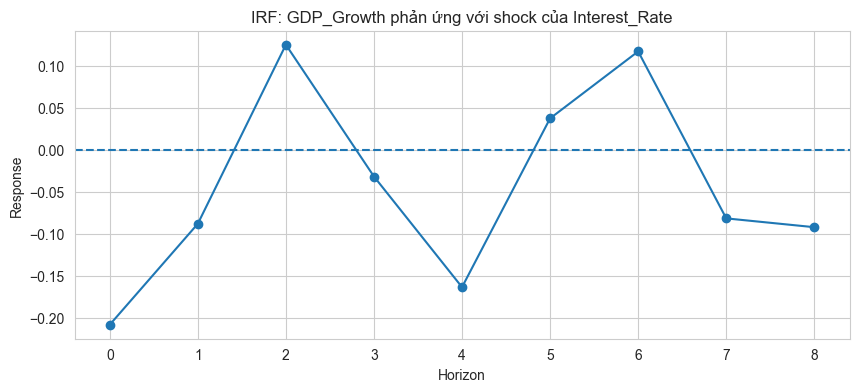

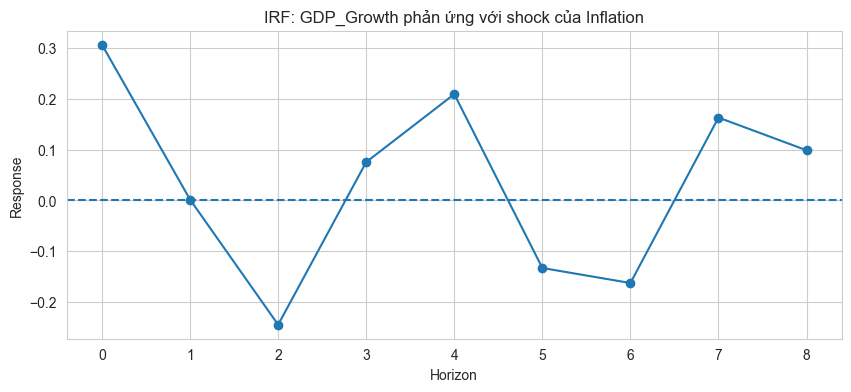

In [6]:

HORIZON = 8
irf = var_res.irf(HORIZON)
irf_array = getattr(irf, "orth_irfs", irf.irfs)

resp_idx = VAR_VARS.index("GDP_Growth")

for impulse in ["Interest_Rate", "Inflation"]:
    imp_idx = VAR_VARS.index(impulse)
    values = irf_array[:, resp_idx, imp_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(range(HORIZON + 1), values, marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(f"IRF: GDP_Growth phản ứng với shock của {impulse}")
    plt.xlabel("Horizon")
    plt.ylabel("Response")
    plt.show()


## 6. FEVD - GDP growth chịu ảnh hưởng bởi shock nào nhiều hơn?


FEVD for Interest_Rate
     Interest_Rate  Inflation  GDP_Growth
0         1.000000   0.000000    0.000000
1         0.927039   0.061942    0.011020
2         0.936362   0.052977    0.010661
3         0.922454   0.048949    0.028597
4         0.925089   0.047185    0.027726
5         0.908352   0.048385    0.043263
6         0.906618   0.048966    0.044417
7         0.898507   0.048525    0.052968

FEVD for Inflation
     Interest_Rate  Inflation  GDP_Growth
0         0.799888   0.200112    0.000000
1         0.823009   0.171943    0.005048
2         0.800430   0.170392    0.029179
3         0.790811   0.166022    0.043167
4         0.786483   0.165964    0.047553
5         0.763474   0.167061    0.069464
6         0.760105   0.169211    0.070684
7         0.745683   0.165993    0.088324

FEVD for GDP_Growth
     Interest_Rate  Inflation  GDP_Growth
0         0.018114   0.039228    0.942658
1         0.019909   0.036604    0.943487
2         0.015684   0.036084    0.948233
3         0.

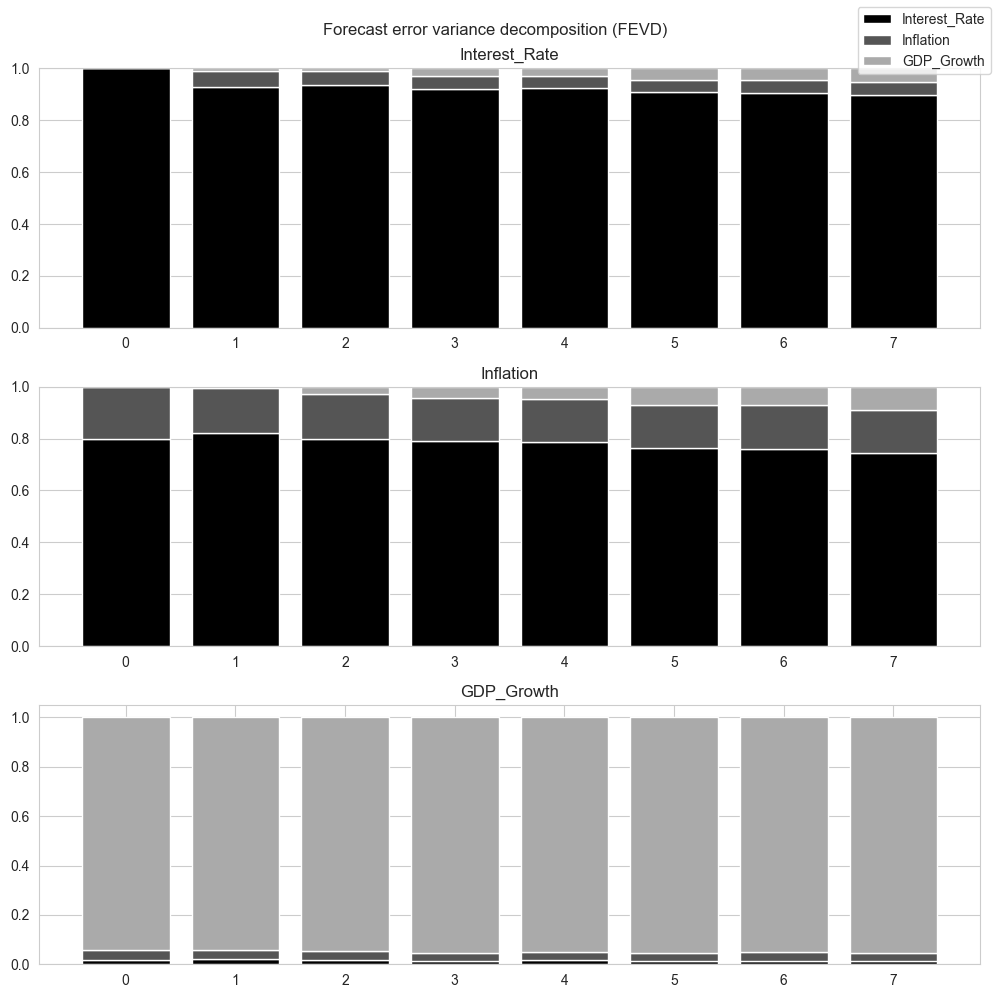

In [7]:

try:
    fevd = var_res.fevd(HORIZON)
    print(fevd.summary())
    fevd.plot()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Không thể tạo FEVD bằng môi trường hiện tại:", exc)


## 7. Dự báo ngắn hạn bằng VAR


In [8]:

lag_order = var_res.k_ar
forecast_steps = 3
forecast_input = var_work[VAR_VARS].values[-lag_order:]
forecast_values = var_res.forecast(y=forecast_input, steps=forecast_steps)

future_years = [int(var_work["Year"].iloc[-1]) + i for i in range(1, forecast_steps + 1)]
forecast_df = pd.DataFrame(forecast_values, columns=VAR_VARS)
forecast_df.insert(0, "Year", future_years)

forecast_df.to_csv(OUTPUT_DIR / "03_var_forecast.csv", index=False)
display(forecast_df)


,Year,Interest_Rate,Inflation,GDP_Growth
0,2024,9.529316,8.972329,-4.793053
1,2025,7.465572,1.056671,4.360223
2,2026,10.161204,4.933083,3.010534


## 8. Kết luận gợi ý cho báo cáo


In [9]:

lines = ["### Kết luận gợi ý cho phần VAR / IRF / FEVD"]

stable_val = diag_df.loc[diag_df["metric"] == "is_stable", "value"].iloc[0]
lines.append(f"- VAR ổn định theo kiểm tra roots/stability: {stable_val}.")

if "whiteness_pvalue" in diag_df["metric"].values:
    p_w = float(diag_df.loc[diag_df["metric"] == "whiteness_pvalue", "value"].iloc[0])
    lines.append(f"- Whiteness p-value = {p_w:.4f}.")

if not granger_df.empty:
    g_best = granger_df.sort_values("p_value").iloc[0]
    lines.append(
        f"- Kiểm định Granger mạnh nhất hiện tại: `{g_best['causing']} -> GDP_Growth`, p-value = {g_best['p_value']:.4f}."
    )

lines.append(
    "- IRF và FEVD nên được dùng trong phần thảo luận chính sách: chúng cho thấy không chỉ dấu của hệ số, mà cả đường đi của cú sốc theo thời gian."
)

summary_text = "\n".join(lines)
display(Markdown(summary_text))

with open(OUTPUT_DIR / "03_var_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)


### Kết luận gợi ý cho phần VAR / IRF / FEVD
- VAR ổn định theo kiểm tra roots/stability: True.
- Whiteness p-value = 0.6190.
- Kiểm định Granger mạnh nhất hiện tại: `Interest_Rate -> GDP_Growth`, p-value = 0.8844.
- IRF và FEVD nên được dùng trong phần thảo luận chính sách: chúng cho thấy không chỉ dấu của hệ số, mà cả đường đi của cú sốc theo thời gian.